In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from tqdm import tqdm 
from scipy.optimize import curve_fit

sys.path.append(os.path.abspath('../src'))
import prep_moth_data as pmd

## Load data:

In [3]:
df_proc = pmd.load_processed_moth_data()
df_proc

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc
0,1994,1995,HV,98,4,15,5944,CG1995,15.0
1,1994,1995,HV,98,44,15,5946,CG1995,8.0
2,1994,1995,HV,98,11,15,5947,CG1995,1.0
3,1994,1995,HV,98,41,15,5949,CG1995,8.0
4,1994,1995,HV,98,41,15,5950,CG1995,8.0
...,...,...,...,...,...,...,...,...,...
7392,2024,2025,WA,1,1,25,21382,CG2025,4.2
7393,2024,2025,WA,1,1,21,21383,CG2025,6.0
7394,2024,2025,WA,2,2,28,21385,CG2025,7.8
7395,2024,2025,WA,2,10,42,21386,CG2025,9.9


In [4]:
df_raw = pmd.load_raw_moth_data()
df_raw

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,AprilDay,Caterpillars
0,1994,1995,HV,98,4,15,5944,CG1995,-14,0.0
1,1994,1995,HV,98,4,15,5944,CG1995,-1,0.0
2,1994,1995,HV,98,4,15,5944,CG1995,5,0.0
3,1994,1995,HV,98,4,15,5944,CG1995,11,0.0
4,1994,1995,HV,98,4,15,5944,CG1995,19,30.0
...,...,...,...,...,...,...,...,...,...,...
119003,2024,2025,WA,2,12,25,21400,CG2025,10,6.0
119004,2024,2025,WA,2,12,25,21400,CG2025,16,8.0
119005,2024,2025,WA,2,12,25,21400,CG2025,17,1.0
119006,2024,2025,WA,2,12,25,21400,CG2025,22,0.0


## Re-calculate D50 for the raw data:

In [5]:
df_raw = pmd.add_relative_caterpillar_counts(df_raw)
print(f"Number of unique tubes in raw data: {df_raw.TubeID.nunique()}")

Number of unique tubes in raw data: 7277


In [6]:
df_proc['RecalculatedD50_linear'] = np.nan 
for i, row in tqdm(df_proc.iterrows()):
    tube_id = row['TubeID']
    if tube_id in df_raw.TubeID.values:
        d50_calc = pmd.calculate_d50_linear_interpolation(df_raw[df_raw.TubeID == tube_id], 
                                 column='CumulativeRelativeCaterpillarsPerTube', verbose=0)
        df_proc.at[i, 'RecalculatedD50_linear'] = d50_calc

df_proc

7397it [00:02, 2470.49it/s]


,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc,RecalculatedD50_linear
0,1994,1995,HV,98,4,15,5944,CG1995,15.0,NaN
1,1994,1995,HV,98,44,15,5946,CG1995,8.0,NaN
2,1994,1995,HV,98,11,15,5947,CG1995,1.0,1.000000
3,1994,1995,HV,98,41,15,5949,CG1995,8.0,NaN
4,1994,1995,HV,98,41,15,5950,CG1995,8.0,NaN
...,...,...,...,...,...,...,...,...,...,...
7392,2024,2025,WA,1,1,25,21382,CG2025,4.2,4.156863
7393,2024,2025,WA,1,1,21,21383,CG2025,6.0,5.980198
7394,2024,2025,WA,2,2,28,21385,CG2025,7.8,7.757576
7395,2024,2025,WA,2,10,42,21386,CG2025,9.9,9.933333


In [7]:
unique_tubes_raw_data = df_raw.TubeID.unique()
unique_tubes_proc_data = df_proc.TubeID.unique()

raw_tubes_not_in_proc = [tube for tube in unique_tubes_raw_data if tube not in unique_tubes_proc_data]
proc_tubes_not_in_raw = [tube for tube in unique_tubes_proc_data if tube not in unique_tubes_raw_data]

print(f"Tubes in raw data but not in processed data: {len(raw_tubes_not_in_proc)}, tubes in processed data but not in raw data: {len(proc_tubes_not_in_raw)}")

Tubes in raw data but not in processed data: 33, tubes in processed data but not in raw data: 0


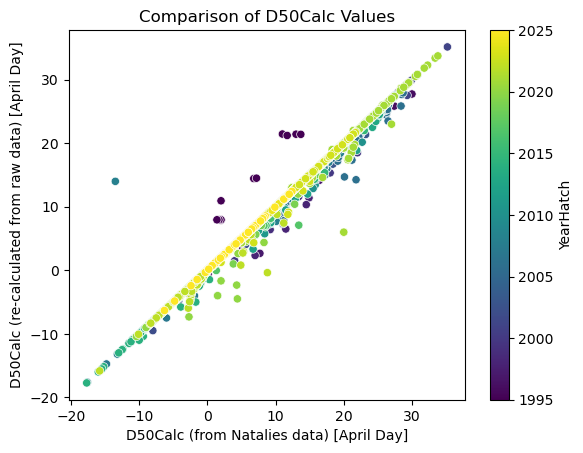

In [8]:
cmap= sns.color_palette('viridis', as_cmap= True)
sm = plt.cm.ScalarMappable(cmap= cmap, norm=mpl.colors.Normalize())
df_plot = df_proc
sns.scatterplot(data=df_plot, x='D50Calc', y='RecalculatedD50_linear', 
                hue='YearHatch', hue_norm=sm.norm, palette=cmap, legend=False)
                # hue='YearHatch', palette='viridis', alpha=0.7)
plt.xlabel('D50Calc (from Natalies data) [April Day]')
plt.ylabel('D50Calc (re-calculated from raw data) [April Day]')
plt.title('Comparison of D50Calc Values')
cbar = plt.colorbar(sm, ax = plt.gca(), label='YearHatch')


## Example tubes:

In [9]:
## Print all mismatched tubes:
mismatched_tubes = df_proc[np.abs(df_proc.D50Calc - df_proc.RecalculatedD50_linear) > 1]
mismatched_tubes

,YearCatch,YearHatch,AreaShortName,Site,Tree,NovemberDate,TubeID,ExperimentName,D50Calc,RecalculatedD50_linear
8,1994,1995,HV,98,48,15,5956,CG1995,2.0,7.909910
9,1994,1995,HV,98,41,18,5969,CG1995,11.0,21.449950
10,1994,1995,HV,98,41,18,5970,CG1995,13.0,21.424925
11,1994,1995,HV,98,41,18,5971,CG1995,11.7,21.224725
12,1994,1995,HV,98,41,18,5972,CG1995,13.7,21.399900
...,...,...,...,...,...,...,...,...,...,...
6830,2021,2022,OH,6,9,29,19050,CG2022,-2.3,-3.306306
7017,2022,2023,OH,2,9,21,19427,CG2023,6.8,4.333333
7088,2022,2023,OH,4,1,42,19564,CG2023,14.0,12.500000
7135,2022,2023,OH,5,2,35,19642,CG2023,11.9,9.137931


In [10]:
## Look at raw data for a specific tube:
tube_id = 16671

d50_original = df_proc[df_proc.TubeID == tube_id].D50Calc.values[0]
d50_recalculated = pmd.calculate_d50_linear_interpolation(df_raw[df_raw.TubeID == tube_id], column='CumulativeRelativeCaterpillarsPerTube', verbose=1)
print(f"\nOriginal D50 for TubeID {tube_id}: {np.round(d50_original, 2)}\nRe-calculated D50 for TubeID {tube_id}: {np.round(d50_recalculated, 2)}")


# df_raw[df_raw.TubeID == tube_id][150:200]

TubeID 16671: max_cp 1, half_cp 0.5, day_bottom 10 (count_bottom 0.5), day_top 10 (count_top 0.5)
count_top == count_bottom for TubeID 16671 with max_cp 1

Original D50 for TubeID 16671: 10.0
Re-calculated D50 for TubeID 16671: 10


## Extapolate:

In [11]:
df_raw_year = df_raw[df_raw.YearHatch > 2020]
df_sigmoid_params, dict_tube_ids = pmd.fit_sigmoid_to_caterpillar_data(df_raw_year, verbose=0)
df_sigmoid_params


# print(f"Fitted parameters: x0={popt[0]}, k={popt[1]}, b={popt[2]}")

# x_fit = np.linspace(df_tube.AprilDay.min(), df_tube.AprilDay.max(), 100)
# y_fit = sigmoid(x_fit, *popt)   

# plt.scatter(df_tube.AprilDay, df_tube.CumulativeRelativeCaterpillarsPerTube, label='Data')
# plt.plot(x_fit, y_fit, color='red', label='Fitted Sigmoid')

 88%|████████▊ | 1202/1366 [00:04<00:00, 288.39it/s]/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pymc_env/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/envs/pym

Success: 853. NaN: 425. No High Count: 0. No Low Count: 83. Fit Fail: 5.


,TubeID,x0,k,D50_Sigmoid
0,16314,9.901707,0.348672,9.901707
1,16315,-2.359043,0.543640,-2.359043
2,16316,7.602500,0.326598,7.602500
3,16317,3.554145,0.316719,3.554145
4,16319,5.013345,0.326681,5.013345
...,...,...,...,...
848,21382,4.082235,0.536984,4.082235
849,21383,5.933753,0.959946,5.933753
850,21385,7.949781,0.590469,7.949781
851,21386,9.924941,0.657415,9.924941


Plotting 83 tubes.


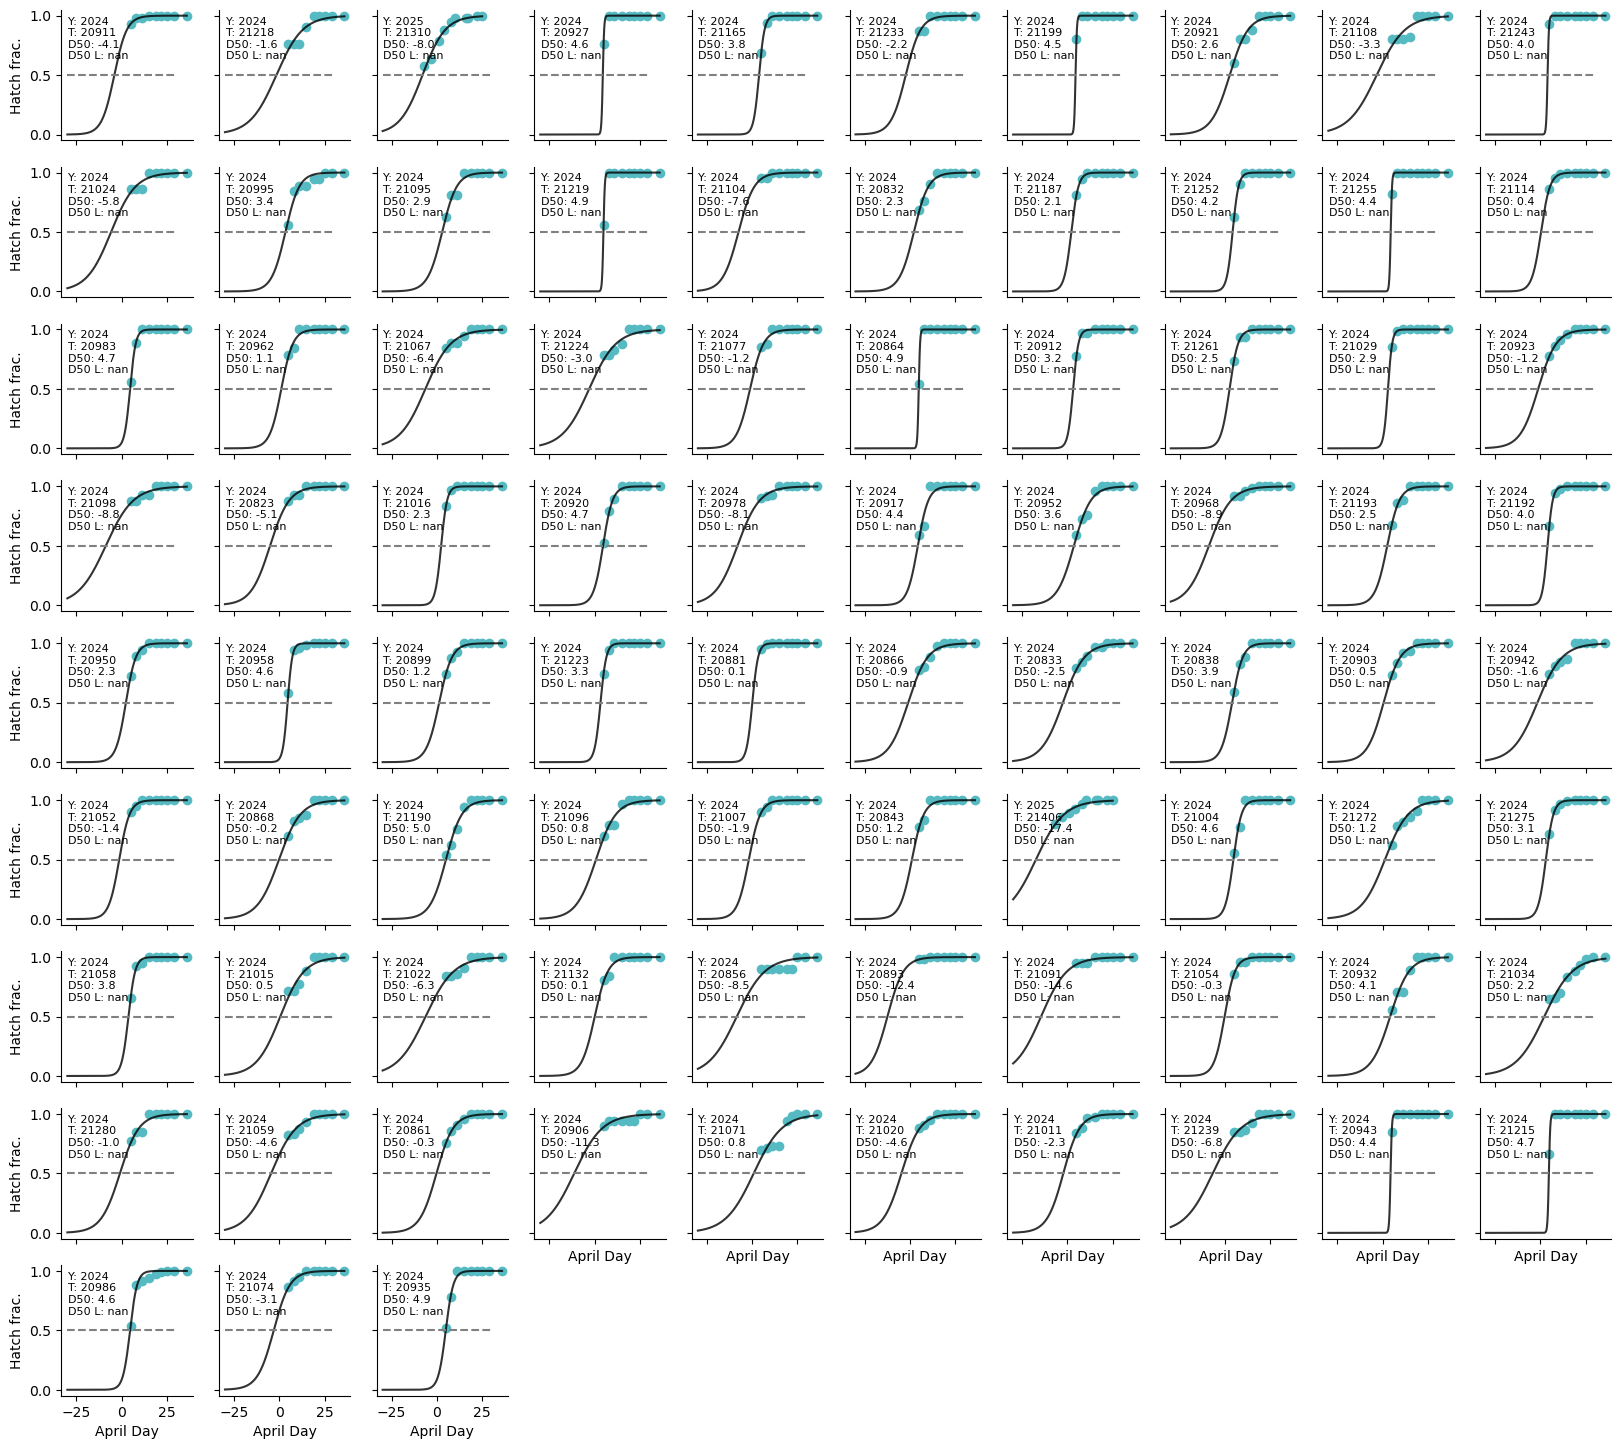

In [12]:
point_estimates = (df_sigmoid_params.x0.median(), df_sigmoid_params.k.median())
hard_bounds_estimates = ((np.percentile(df_sigmoid_params.x0, 0), np.percentile(df_sigmoid_params.k, 0.5)),
                         (np.percentile(df_sigmoid_params.x0, 100), np.percentile(df_sigmoid_params.k, 99.5)))

tube_ids_use = dict_tube_ids['no_low_count']
tube_ids_use = np.random.choice(a=tube_ids_use, size=len(tube_ids_use), replace=False)  # shuffle order
n_plot = min(len(tube_ids_use), 100)
n_cols = 10
n_rows = int(np.ceil(n_plot / n_cols))

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2), squeeze=False, sharex=True, sharey=True)
print(f"Plotting {n_plot} tubes.")

for iloop, tube_id in enumerate(tube_ids_use):
    if iloop >= n_plot:
        break
    df_tube = df_raw_year[df_raw_year.TubeID == tube_id]
    try:
        popt, pcov = curve_fit(pmd.sigmoid, df_tube.AprilDay, df_tube.CumulativeRelativeCaterpillarsPerTube, 
                               p0=point_estimates, bounds=(hard_bounds_estimates), maxfev=10000)
    except RuntimeError as e:
        print(f"Could not fit sigmoid for TubeID {tube_id} again: {e}")
        continue

    curr_ax = ax.flatten()[iloop]
    curr_ax.scatter(df_tube.AprilDay, df_tube.CumulativeRelativeCaterpillarsPerTube, color="#56bac3", alpha=1)
    x_fit = np.linspace(-30, df_tube.AprilDay.max(), 10000)
    y_fit = pmd.sigmoid(x_fit, *popt)
    d50 = popt[0]
    curr_ax.plot(x_fit, y_fit, color='k', alpha=0.8)
    curr_ax.hlines(0.5, xmin=-30, xmax=30, colors='gray', linestyles='dashed')
    
    processed_data = df_proc[df_proc.TubeID == tube_id]
    if len(processed_data) > 1:
        print(f"Warning: multiple entries in processed data for TubeID {tube_id}")
    elif len(processed_data) == 0:
        str_d50_linear = ''
    else:
        d50_linear = processed_data.D50Calc.values[0]
        str_d50_linear = f'D50 L: {d50_linear:.1f}'

    curr_ax.annotate(f'Y: {df_tube.YearHatch.values[0]}\nT: {tube_id}\nD50: {d50:.1f}\n{str_d50_linear}', 
                    xy=(0.05, 0.95), xycoords='axes fraction', fontsize=8, color='black', va='top')
    
    for sp in ['top', 'right']:
        curr_ax.spines[sp].set_visible(False)
    if iloop >= n_plot:
        break
    
for ii in range(n_plot, n_cols * n_rows):
    curr_ax = ax.flatten()[ii]
    curr_ax.axis('off')

for ii in range(n_rows):
    ax[ii][0].set_ylabel('Hatch frac.')
for jj in range(n_cols):
    if jj >= n_plot % n_cols:
        row_plot = -2 
    else:
        row_plot = -1
    ax[row_plot][jj].set_xlabel('April Day')

    